
**KNN imputation is a method to fill in missing values in a dataset using nearby data points.**

- **Identify the missing data:** Find where you have missing values in your dataset.

- **Choose a K value:** Decide how many nearby data points (neighbors) you want to consider when filling in the missing value.

- **Measure distances:** Calculate the distances between the data point with the missing value and all other data points in the dataset.

- **Select the closest neighbors:** Choose the K nearest data points with complete information to the one with the missing value.

- **Impute the missing value:** Average or combine the values from the selected neighbors to fill in the missing value.

- **Repeat for all missing values:** Apply the same process to all the missing values in your dataset.

- **Finish:** Once you've filled in all the missing values, your dataset is ready for analysis.

**ADVANTAGE**   ...............ACCURATE

**DISADVANTAGE**.........TIME CONSUMING AND MEMORY HEAVY ON DEPLOYMENT

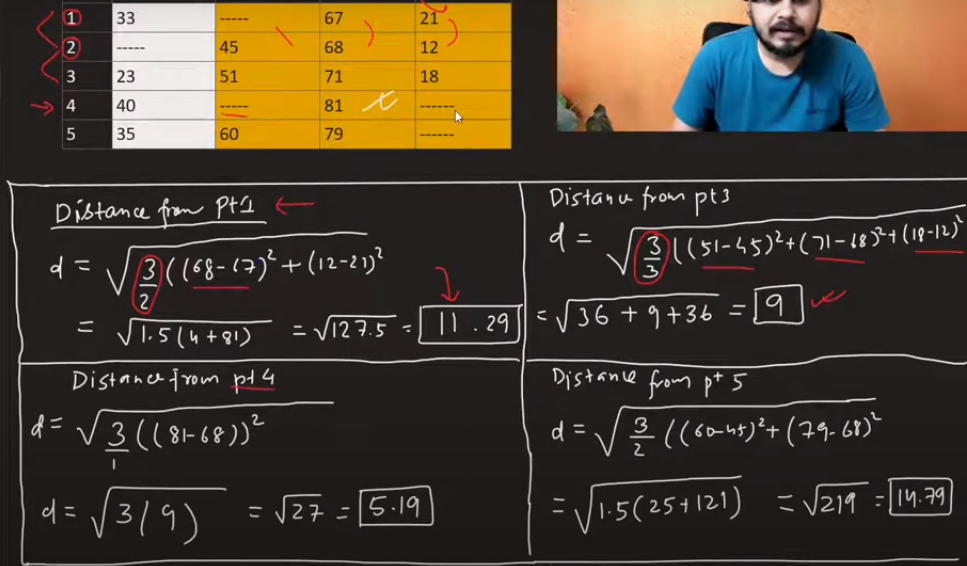

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
df = pd.read_csv('train.csv')[['Age','Pclass','Fare','Survived']]
df.head()

,Age,Pclass,Fare,Survived
0,22.0,3,7.2500,0
1,38.0,1,71.2833,1
2,26.0,3,7.9250,1
3,35.0,1,53.1000,1
4,35.0,3,8.0500,0


In [2]:
df.isnull().mean() * 100

Age         19.86532
Pclass       0.00000
Fare         0.00000
Survived     0.00000
dtype: float64

In [3]:
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
X_train.head()

,Age,Pclass,Fare
30,40.0,1,27.7208
10,4.0,3,16.7000
873,47.0,3,9.0000
182,9.0,3,31.3875
876,20.0,3,9.8458


In KNN imputation, the "weight parameter" refers to a factor that assigns different levels of importance or influence to the neighboring data points when imputing a missing value. This parameter allows you to control how much each nearby data point contributes to the imputed value of the missing data point.

Typically, in KNN imputation, there are two common ways to assign weights:

**Uniform Weighting:** In this approach, all the neighboring data points within the specified K nearest neighbors are given equal importance or weight. This means that each neighbor contributes equally to the imputed value, regardless of their distance from the missing data point.

**Distance Weighting:** With distance weighting, closer neighbors have a greater influence on the imputed value, while farther neighbors have less influence. The weight of each neighbor is inversely proportional to its distance from the missing data point. Closer neighbors have higher weights, and farther neighbors have lower weights.

In [6]:
knn = KNNImputer(n_neighbors=3,weights='distance',add_indicator=True)
X_train_trf = knn.fit_transform(X_train)
X_test_trf = knn.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_trf,y_train)
y_pred = lr.predict(X_test_trf)
accuracy_score(y_test,y_pred)

0.7150837988826816



---



---



In [5]:
# Comparision with Simple Imputer --> mean

si = SimpleImputer()
X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 = si.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_trf2,y_train)
y_pred2 = lr.predict(X_test_trf2)
accuracy_score(y_test,y_pred2)

0.6927374301675978